In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
!pip install lunardate optuna

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from lunardate import LunarDate
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_DIR = '/content/drive/MyDrive/datathon-2026-round-1/'

TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'
PROMO_FILE = DATA_DIR + 'promotions.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'

TET = {y: pd.Timestamp(LunarDate(y, 1, 1).toSolarDate()) for y in range(2010, 2030)}

def calc_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

In [60]:
print("1. Đang tải dữ liệu chính...")
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE, parse_dates=['Date'])

train['year'] = train['Date'].dt.year; train['month'] = train['Date'].dt.month; train['day'] = train['Date'].dt.day
test['year']  = test['Date'].dt.year;  test['month']  = test['Date'].dt.month;  test['day']  = test['Date'].dt.day

print("2. Xây dựng Seasonal Base Forecast...")
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
full_years = annual.loc[2013:2022]
yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

seasonal = train.groupby(['month', 'day'])[['rev_norm', 'cogs_norm']].mean().reset_index()
train = train.drop(columns=['rev_norm', 'cogs_norm'])

base_rev  = annual.loc[2022, 'Revenue'] / 365
base_cogs = annual.loc[2022, 'COGS']    / 365

full_base = pd.concat([train, test], ignore_index=True)
full_base['years_ahead'] = full_base['year'] - 2022
full_base = full_base.merge(seasonal, on=['month', 'day'], how='left').fillna({'rev_norm': 1.0, 'cogs_norm': 1.0})

full_base['Revenue_base_pred'] = base_rev * growth_rev**full_base['years_ahead'] * full_base['rev_norm']
full_base['COGS_base_pred']    = base_cogs * growth_cogs**full_base['years_ahead'] * full_base['cogs_norm']

full_base['Revenue_residual'] = full_base['Revenue'] - full_base['Revenue_base_pred']
full_base['COGS_residual']    = full_base['COGS'] - full_base['COGS_base_pred']

1. Đang tải dữ liệu chính...
2. Xây dựng Seasonal Base Forecast...


In [61]:
print("3. Thực hiện Feature Engineering từ các bảng phụ...")

# --- 1. WEB TRAFFIC ---
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic_updated.csv', parse_dates=['date'])
web_traffic['year'] = web_traffic['date'].dt.year
web_traffic['month'] = web_traffic['date'].dt.month
web_traffic['day'] = web_traffic['date'].dt.day
web_traffic['day_of_week'] = web_traffic['date'].dt.day_name()
web_traffic['week'] = web_traffic['date'].dt.isocalendar().week
web_traffic['is_weekend'] = web_traffic['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
web_traffic['pages_per_session'] = web_traffic['page_views'] / web_traffic['sessions']
web_traffic['sessions_per_user'] = web_traffic['sessions'] / web_traffic['unique_visitors']
web_traffic['avg_time_per_page'] = web_traffic['avg_session_duration_sec'] / web_traffic['page_views']
web_traffic['bounce_rate_level'] = pd.cut(web_traffic['bounce_rate'], bins=[0, 0.4, 0.7, 1], labels=['Low', 'Medium', 'High']).cat.codes
web_traffic['sessions_7d'] = web_traffic['sessions'].rolling(7).mean()
web_traffic['z_sessions'] = (web_traffic['sessions'] - web_traffic['sessions'].mean()) / web_traffic['sessions'].std()

# Tổng hợp Web theo ngày
web_daily = web_traffic.groupby('date').mean(numeric_only=True).reset_index().rename(columns={'date': 'Date'})


# --- 2. INVENTORY ---
inventory = pd.read_csv(DATA_DIR + 'inventory_updated.csv', parse_dates=['snapshot_date'])
inventory["year_month"] = inventory["snapshot_date"].dt.to_period("M").astype(str)
inventory["net_inventory_change"] = inventory["units_received"] - inventory["units_sold"]
inventory["inventory_turnover_rate"] = np.where(inventory["stock_on_hand"] > 0, inventory["units_sold"] / inventory["stock_on_hand"], np.nan)
inventory["sell_through_rate_calc"] = np.where((inventory["stock_on_hand"] + inventory["units_received"]) > 0, inventory["units_sold"] / (inventory["stock_on_hand"] + inventory["units_received"]), np.nan)
inventory["critical_stock_flag"] = (inventory["days_of_supply"] < 7).astype(int)
inventory["service_level_gap"] = 1 - inventory["fill_rate"]
inventory["stockout_risk_score"] = (inventory["stockout_days"] * 0.4 + inventory["service_level_gap"] * 100 * 0.4 + (inventory["critical_stock_flag"] * 100) * 0.2)
inventory["overstock_intensity"] = np.where(inventory["units_sold"] > 0, inventory["stock_on_hand"] / inventory["units_sold"], np.nan)
inventory["stock_efficiency_score"] = np.where((inventory["stock_on_hand"] + inventory["units_received"]) > 0, inventory["units_sold"] / (inventory["stock_on_hand"] + inventory["units_received"]), np.nan)
inventory["sales_velocity"] = np.where(inventory["stockout_days"] > 0, inventory["units_sold"] / inventory["stockout_days"], inventory["units_sold"])
inventory["reorder_urgency_score"] = ((inventory["reorder_flag"] * 50) + (inventory["critical_stock_flag"] * 30) + ((1 - inventory["fill_rate"]) * 20))
inventory["inventory_health_score"] = (inventory["fill_rate"] * 40 + (inventory["days_of_supply"].clip(0, 30) / 30) * 30 + (1 - inventory["stockout_flag"]) * 20 + (1 - inventory["overstock_flag"]) * 10)

# Tổng hợp Inventory theo ngày
inv_daily = inventory.groupby('snapshot_date').mean(numeric_only=True).reset_index().rename(columns={'snapshot_date': 'Date'})


# --- 3. ORDERS ---
orders = pd.read_csv(DATA_DIR + 'orders_updated.csv', parse_dates=['order_date'])
orders['order_year'] = orders['order_date'].dt.year
orders['order_is_weekend'] = orders['order_date'].dt.dayofweek.isin([5,6]).astype(int)
orders['prev_order_date'] = orders.groupby('customer_id')['order_date'].shift(1)
orders['days_since_last_order'] = (orders['order_date'] - orders['prev_order_date']).dt.days.fillna(-1)
orders['customer_total_orders'] = orders.groupby('customer_id')['order_id'].transform('count')
orders['is_delivered'] = (orders['order_status'] == 'delivered').astype(int)
orders['is_cancelled'] = (orders['order_status'] == 'cancelled').astype(int)
orders['is_returned'] = (orders['order_status'] == 'returned').astype(int)
orders['customer_delivery_rate'] = orders.groupby('customer_id')['is_delivered'].transform('mean')
orders['customer_cancel_rate'] = orders.groupby('customer_id')['is_cancelled'].transform('mean')
orders['customer_return_rate'] = orders.groupby('customer_id')['is_returned'].transform('mean')
orders['num_devices_used'] = orders.groupby('customer_id')['device_type'].transform('nunique')
orders['num_sources_used'] = orders.groupby('customer_id')['order_source'].transform('nunique')

# Tổng hợp Orders theo ngày
orders_daily = orders.groupby('order_date').mean(numeric_only=True).reset_index().rename(columns={'order_date': 'Date'})
# Tính thêm tổng số đơn hàng trong ngày
orders_daily['total_daily_orders'] = orders.groupby('order_date').size().values


# --- GỘP BẢNG VÀ DỊCH CHUYỂN (SHIFT 364 NGÀY) ---
extra_df = web_daily.merge(inv_daily, on='Date', how='outer').merge(orders_daily, on='Date', how='outer')
extra_df = extra_df.sort_values("Date").fillna(method='ffill').fillna(0)

# Tạo ngày mục tiêu (Đẩy dữ liệu này về tương lai để dùng cho dự báo)
extra_df['Target_Date'] = extra_df['Date'] + pd.Timedelta(days=364)

# Đổi tên các cột (thêm hậu tố _lag364)
rename_dict = {col: f"{col}_lag364" for col in extra_df.columns if col not in ['Date', 'Target_Date']}
extra_df = extra_df.rename(columns=rename_dict).drop(columns=['Date'])

3. Thực hiện Feature Engineering từ các bảng phụ...


In [62]:
print("4. Xử lý Promotions & Tính năng Mở rộng...")

# --- 4. PROMOTIONS (Mới) ---
promotions = pd.read_csv(PROMO_FILE, parse_dates=['start_date', 'end_date'])
promotions['is_weekend_start'] = promotions['start_date'].dt.dayofweek.isin([5, 6]).astype(int)

# Tỷ lệ giảm giá thực tế theo logic của bạn
promotions['effective_discount_rate'] = np.where(
    promotions['promo_type'] == 'percent',
    promotions['discount_value'] / 100,
    np.where(promotions['min_order_value'] > 0, promotions['discount_value'] / promotions['min_order_value'], 0)
)
promotions['min_order_norm'] = (promotions['min_order_value'] - promotions['min_order_value'].mean()) / promotions['min_order_value'].std()
promotions['promo_score'] = promotions['effective_discount_rate'] + promotions['stackable_flag'] * 0.1 - promotions['min_order_norm'] * 0.05

def build_daily_promos(promos_df, date_range):
    promo_list = []
    for _, row in promos_df.iterrows():
        temp = pd.DataFrame({'Date': pd.date_range(row['start_date'], row['end_date'])})
        temp['promo_score'] = row['promo_score']
        temp['effective_discount_rate'] = row['effective_discount_rate']
        temp['is_stackable'] = row['stackable_flag']
        promo_list.append(temp)
    if promo_list:
        promo_df = pd.concat(promo_list, ignore_index=True)
        return promo_df.groupby('Date').agg(
            active_promos_count=('Date', 'count'),
            max_promo_score=('promo_score', 'max'),
            max_discount_rate=('effective_discount_rate', 'max')
        ).reset_index()
    return pd.DataFrame({'Date': date_range, 'active_promos_count': 0, 'max_promo_score': 0.0, 'max_discount_rate': 0.0})

# Gắn đặc trưng thời gian
full_base['dow'] = full_base['Date'].dt.dayofweek.astype(int)
full_base['is_weekend'] = (full_base['dow'] >= 5).astype(int)

# Multi-Window Lags cho Residual
full_base['Rev_resid_lag_364'] = full_base['Revenue_residual'].shift(364).fillna(0)
full_base['Rev_resid_lag_365'] = full_base['Revenue_residual'].shift(365).fillna(0)
full_base['Rev_resid_lag_357'] = full_base['Revenue_residual'].shift(357).fillna(0)
full_base['Rev_resid_lag_371'] = full_base['Revenue_residual'].shift(371).fillna(0)
full_base['Rev_resid_last_year_neighborhood'] = (full_base['Rev_resid_lag_364'] + full_base['Rev_resid_lag_365'] + full_base['Rev_resid_lag_357'] + full_base['Rev_resid_lag_371']) / 4.0
full_base['COGS_resid_lag_364'] = full_base['COGS_residual'].shift(364).fillna(0)

# Merge Khuyến mãi mới
daily_promo = build_daily_promos(promotions, full_base['Date'].unique())
full_feat = full_base.merge(daily_promo, on='Date', how='left').fillna(0)

# Merge Extra Features (đã shift)
full_feat = full_feat.merge(extra_df, left_on='Date', right_on='Target_Date', how='left').drop(columns=['Target_Date'])
full_feat = full_feat.fillna(method='ffill').fillna(0)

# Kỹ thuật Winsorization (Chặn Outliers)
cols_to_clip = ['Revenue_residual', 'COGS_residual', 'Rev_resid_lag_364']
for col in cols_to_clip:
    if col in full_feat.columns:
        full_feat[col] = full_feat[col].clip(lower=full_feat[col].quantile(0.01), upper=full_feat[col].quantile(0.99))

TRAIN_END = train['Date'].max()
TEST_START = test['Date'].min()

# Loại bỏ 2 năm đầu tiên bị rỗng dữ liệu Lag 364
train_feat = full_feat[(full_feat['Date'] <= TRAIN_END) & (full_feat['year'] >= 2015)].copy()
test_feat  = full_feat[full_feat['Date'] >= TEST_START].copy()

4. Xử lý Promotions & Tính năng Mở rộng...


In [63]:
EXCLUDE = [
    'Date', 'Revenue', 'COGS', 'Revenue_base_pred', 'COGS_base_pred',
    'Revenue_residual', 'COGS_residual', 'base_rev', 'base_cogs',
    'year', 'years_ahead'
]

FEATURES = [c for c in train_feat.columns if c not in EXCLUDE]
print(f"Tổng số Features đưa vào XGBoost: {len(FEATURES)}")

Tổng số Features đưa vào XGBoost: 83


In [64]:
print("5. Bắt đầu TimeSeries Cross-Validation với XGBoost...")

# Tham số vàng Optuna
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.0060886996413935315,
    'max_depth': 9,
    'subsample': 0.7437997637145483,
    'colsample_bytree': 0.660990094677646,
    'min_child_weight': 6,
    'reg_alpha': 1.6685524900604345,
    'reg_lambda': 4.069195369987692,
    'n_estimators': 3000,
    'early_stopping_rounds': 100,
    'random_state': 42
}

tscv = TimeSeriesSplit(n_splits=5)
models_rev = []; models_cogs = []
metrics_list = []

X = train_feat[FEATURES]
y_rev = train_feat['Revenue_residual']
y_cogs = train_feat['COGS_residual']
y_rev_true = train_feat['Revenue']

fold = 1
for train_index, val_index in tscv.split(X):
    print(f"\n--- FOLD {fold} ---")
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    yr_train, yr_val = y_rev.iloc[train_index], y_rev.iloc[val_index]
    yc_train, yc_val = y_cogs.iloc[train_index], y_cogs.iloc[val_index]

    model_r = xgb.XGBRegressor(**xgb_params)
    model_r.fit(X_train, yr_train, eval_set=[(X_val, yr_val)], verbose=False)
    models_rev.append(model_r)

    model_c = xgb.XGBRegressor(**xgb_params)
    model_c.fit(X_train, yc_train, eval_set=[(X_val, yc_val)], verbose=False)
    models_cogs.append(model_c)

    val_resid_pred = model_r.predict(X_val)
    val_final_pred = train_feat['Revenue_base_pred'].iloc[val_index] + val_resid_pred
    val_true = y_rev_true.iloc[val_index]

    rmse = np.sqrt(mean_squared_error(val_true, val_final_pred))
    mae = mean_absolute_error(val_true, val_final_pred)
    r2 = r2_score(val_true, val_final_pred)
    mape = calc_mape(val_true, val_final_pred)

    print(f"RMSE: {rmse:,.0f} | MAE: {mae:,.0f} | R2: {r2:.4f} | MAPE: {mape:.2f}%")
    metrics_list.append({'Fold': fold, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape})
    fold += 1

print("\n=== ĐÁNH GIÁ SỨC MẠNH THỰC SỰ ===")
print(pd.DataFrame(metrics_list).iloc[-1])

5. Bắt đầu TimeSeries Cross-Validation với XGBoost...

--- FOLD 1 ---
RMSE: 1,481,185 | MAE: 1,094,614 | R2: 0.7850 | MAPE: 22.77%

--- FOLD 2 ---
RMSE: 1,185,705 | MAE: 851,677 | R2: 0.8324 | MAPE: 21.71%

--- FOLD 3 ---
RMSE: 1,884,063 | MAE: 1,658,276 | R2: -0.2201 | MAPE: 66.93%

--- FOLD 4 ---
RMSE: 765,731 | MAE: 542,940 | R2: 0.7864 | MAPE: 21.70%

--- FOLD 5 ---
RMSE: 696,248 | MAE: 506,262 | R2: 0.8090 | MAPE: 20.07%

=== ĐÁNH GIÁ SỨC MẠNH THỰC SỰ ===
Fold         5.000000
RMSE    696247.688270
MAE     506262.136829
R2           0.808975
MAPE        20.065952
Name: 4, dtype: float64


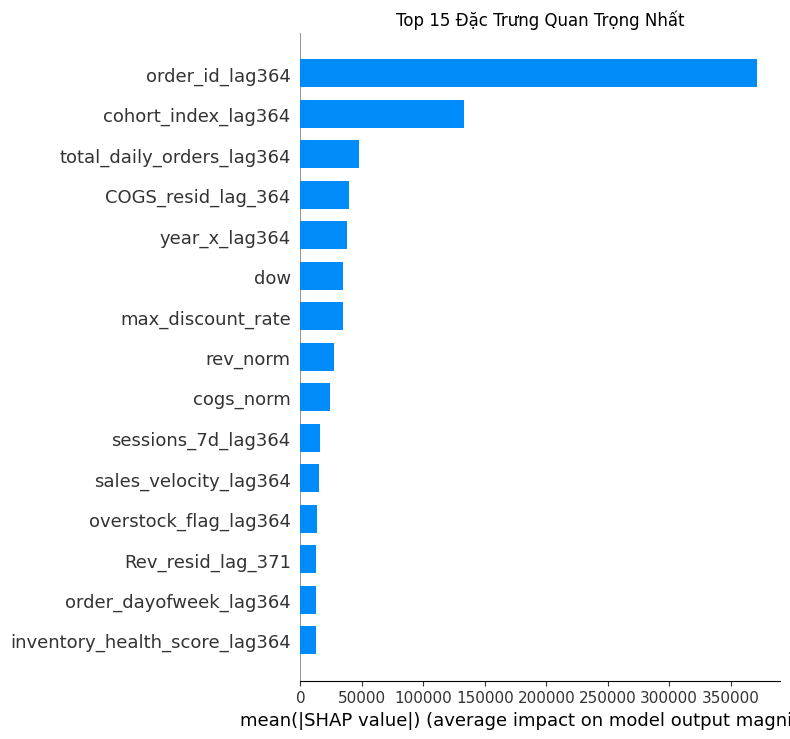

In [65]:
best_model = models_rev[-1]
explainer = shap.TreeExplainer(best_model)
sample_X = X.tail(2000)
shap_values = explainer.shap_values(sample_X)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, sample_X, plot_type="bar", max_display=15, show=False)
plt.title("Top 15 Đặc Trưng Quan Trọng Nhất")
plt.tight_layout()
plt.show()

In [66]:
print("7. Dự báo tập Test (Ensemble 5 Folds)...")

X_test = test_feat[FEATURES]

test_rev_resid = np.zeros(len(X_test))
test_cogs_resid = np.zeros(len(X_test))

for i in range(5):
    test_rev_resid += models_rev[i].predict(X_test)
    test_cogs_resid += models_cogs[i].predict(X_test)

test_rev_resid /= 5.0
test_cogs_resid /= 5.0

test_feat['Revenue'] = (test_feat['Revenue_base_pred'] + test_rev_resid).round(2)
test_feat['COGS']    = (test_feat['COGS_base_pred'] + test_cogs_resid).round(2)

test_feat['Revenue'] = test_feat['Revenue'].clip(lower=0)
test_feat['COGS']    = test_feat['COGS'].clip(lower=0)

submission = test_feat[['Date', 'Revenue', 'COGS']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f"=== ĐÃ HOÀN TẤT ===")
print(f"Lưu {len(submission)} dòng vào: {OUT_FILE}")
print(submission.head())

7. Dự báo tập Test (Ensemble 5 Folds)...
=== ĐÃ HOÀN TẤT ===
Lưu 548 dòng vào: /content/drive/MyDrive/datathon-2026-round-1/submission.csv
            Date     Revenue        COGS
3833  2023-01-01  3135886.62  2810478.95
3834  2023-01-02  1736560.17  1427202.79
3835  2023-01-03  1441345.45  1086180.57
3836  2023-01-04  1573402.15  1179205.57
3837  2023-01-05  1593340.17  1177046.78
